In [1]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import dice_ml

from collections import Counter

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Layer,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
train_data = pd.read_csv(
    "datasets/CICIDS2017/train_test/CICIDS2017_Train_80.csv"
)

print(train_data.shape)

(1948553, 41)


In [4]:
train_data.head()

,rst_flag_counts,payload_bytes_variance,dst_port,fwd_packets_IAT_mean,bwd_packets_IAT_mean,payload_bytes_mean,packets_IAT_mean,payload_bytes_max,src_port,bwd_rst_flag_counts,...,subflow_fwd_packets,fwd_packets_IAT_std,bytes_rate,fwd_max_header_bytes,bwd_bytes_rate,subflow_fwd_bytes,psh_flag_counts,fwd_std_header_bytes,fwd_bytes_rate,label
0,-0.694944,-0.340160,-0.391287,1.494661,1.848223,-0.209076,-0.533777,-0.402610,0.899134,-0.413177,...,-0.004675,-0.18969,-0.045026,-0.854678,-0.027341,-0.073397,-0.041523,-0.579689,-0.036039,0
1,1.438964,-0.343442,2.668527,1.494913,1.848502,-0.589495,-0.533777,-0.489615,0.229764,2.420268,...,-0.004675,-0.18969,-0.045336,1.396727,-0.027749,-0.073397,-0.041523,-0.579689,-0.036122,9
2,-0.694944,-0.343442,3.015490,-0.669038,1.848481,-0.589495,1.873748,-0.489615,-2.052671,-0.413177,...,-0.004675,-0.18969,-0.045336,-1.417529,-0.027749,-0.073397,-0.041523,-0.579689,-0.036122,0
3,-0.694944,-0.343442,2.992763,-0.669038,1.848088,-0.589495,1.873351,-0.489615,-2.052671,-0.413177,...,-0.004675,-0.18969,-0.045336,-1.417529,-0.027749,-0.073397,-0.041523,-0.579689,-0.036122,0
4,-0.694944,-0.343050,-0.391287,-0.669038,-0.541044,-0.412073,-0.533777,-0.452859,-1.089183,-0.413177,...,-0.004675,-0.18969,0.025399,-0.854678,0.056559,-0.073397,-0.041523,-0.579689,-0.010516,0


In [5]:
feature_names = train_data.drop(
    columns=["label"]
).columns.tolist()

print("Number of Features:", len(feature_names))

Number of Features: 40


In [6]:
dice_train_df = train_data.copy()

print(dice_train_df.shape)

(1948553, 41)


In [7]:
DICE_TRAIN_SIZE = 50000

dice_train_df = dice_train_df.sample(

    n=DICE_TRAIN_SIZE,

    random_state=42

)

print(dice_train_df.shape)

(50000, 41)


In [8]:
dice_data = dice_ml.Data(

    dataframe=dice_train_df,

    continuous_features=feature_names,

    outcome_name="label"

)

print("DiCE Data Created")

DiCE Data Created


In [9]:
@tf.keras.utils.register_keras_serializable()
class FeatureTokenizer(Layer):

    def __init__(self, num_features, embed_dim, **kwargs):

        super().__init__(**kwargs)

        self.num_features = num_features

        self.embed_dim = embed_dim

        self.proj = Dense(embed_dim)

    def build(self, input_shape):

        self.feature_embedding = self.add_weight(

            name="feature_embedding",

            shape=(1,self.num_features,self.embed_dim),

            initializer="random_normal",

            trainable=True

        )

    def call(self,x):

        x=tf.expand_dims(x,-1)

        x=self.proj(x)

        return x+self.feature_embedding

    def get_config(self):

        config=super().get_config()

        config.update({

            "num_features":self.num_features,

            "embed_dim":self.embed_dim

        })

        return config

In [10]:
@tf.keras.utils.register_keras_serializable()
class CLSToken(Layer):

    def build(self,input_shape):

        self.cls=self.add_weight(

            name="cls_token",

            shape=(1,1,input_shape[-1]),

            initializer="zeros",

            trainable=True

        )

    def call(self,x):

        batch=tf.shape(x)[0]

        cls=tf.repeat(self.cls,batch,axis=0)

        return tf.concat([cls,x],axis=1)

In [11]:
@tf.keras.utils.register_keras_serializable()
class PositionEmbedding(Layer):

    def __init__(

        self,

        sequence_length,

        embed_dim,

        **kwargs

    ):

        super().__init__(**kwargs)

        self.sequence_length=sequence_length

        self.embed_dim=embed_dim

    def build(self,input_shape):

        self.pos_embedding=self.add_weight(

            name="position_embedding",

            shape=(1,self.sequence_length,self.embed_dim),

            initializer="random_normal",

            trainable=True

        )

    def call(self,x):

        return x+self.pos_embedding

    def get_config(self):

        config=super().get_config()

        config.update({

            "sequence_length":self.sequence_length,

            "embed_dim":self.embed_dim

        })

        return config

In [ ]:

@tf.keras.utils.register_keras_serializable()
class TransformerBlock(Layer):

    def __init__(

        self,

        embed_dim,

        num_heads,

        ff_dim,

        dropout=0.15,

        **kwargs

    ):

        super().__init__(**kwargs)

        self.embed_dim=embed_dim

        self.num_heads=num_heads

        self.ff_dim=ff_dim

        self.dropout_rate=dropout

        self.norm1=LayerNormalization(epsilon=1e-6)

        self.att=MultiHeadAttention(

            num_heads=num_heads,

            key_dim=embed_dim//num_heads,

            dropout=dropout

        )

        self.drop1=Dropout(dropout)

        self.norm2=LayerNormalization(epsilon=1e-6)

        self.ffn=tf.keras.Sequential([

            Dense(ff_dim,activation="gelu"),

            Dropout(dropout),

            Dense(embed_dim)

        ])

        self.drop2=Dropout(dropout)

    def call(self,x,training=False):

        y=self.norm1(x)

        y=self.att(y,y,training=training)

        y=self.drop1(y,training=training)

        x=x+y

        y=self.norm2(x)

        y=self.ffn(y,training=training)

        y=self.drop2(y,training=training)

        return x+y

    def get_config(self):

        config=super().get_config()

        config.update({

            "embed_dim":self.embed_dim,

            "num_heads":self.num_heads,

            "ff_dim":self.ff_dim,

            "dropout":self.dropout_rate

        })

        return config

In [13]:
model = load_model(

    "Transformer_IDS_Final.keras",

    custom_objects={

        "FeatureTokenizer":FeatureTokenizer,

        "CLSToken":CLSToken,

        "PositionEmbedding":PositionEmbedding,

        "TransformerBlock":TransformerBlock

    },

    compile=False

)

print(model.summary())

c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'transformer_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'transformer_block_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "FTTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_tokenizer_1             │ (None, 40, 192)        │         8,064 │
│ (FeatureTokenizer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cls_token_1 (CLSToken)          │ (None, 41, 192)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ position_embedding_1            │ (None, 41, 192)        │         7,872 │
│ (PositionEmbedding)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 41, 192)        │       247,744 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 41, 192)        │       247,744 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_13          │ (None, 192)            │           384 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,870 (2.08 MB)

 Trainable params: 545,870 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

None


In [14]:
sample = dice_train_df.drop(

    columns=["label"]

).iloc[:5]

pred = model.predict(sample)

print(pred.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
(5, 14)


In [15]:
dice_model = dice_ml.Model(

    model=model,

    backend="TF2",

    model_type="classifier"

)

print("DiCE Model Created")

DiCE Model Created


In [16]:
explainer = dice_ml.Dice(

    dice_data,

    dice_model,

    method="random"

)

print("DiCE Explainer Ready")

DiCE Explainer Ready


In [17]:
print("Available Classes:\n")

print(sorted(dice_train_df["label"].unique()))

Available Classes:

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]


In [18]:
print(dice_train_df["label"].value_counts())

label
0     36721
4      7181
9      3246
2      1958
7       184
3       171
5       126
10      120
6       106
1       103
11       54
13       29
12        1
Name: count, dtype: int64


In [19]:
query_instance = dice_train_df.drop(
    columns=["label"]
).iloc[[0]]

query_instance

,rst_flag_counts,payload_bytes_variance,dst_port,fwd_packets_IAT_mean,bwd_packets_IAT_mean,payload_bytes_mean,packets_IAT_mean,payload_bytes_max,src_port,bwd_rst_flag_counts,...,down_up_rate,subflow_fwd_packets,fwd_packets_IAT_std,bytes_rate,fwd_max_header_bytes,bwd_bytes_rate,subflow_fwd_bytes,psh_flag_counts,fwd_std_header_bytes,fwd_bytes_rate
886409,1.438964,-0.343442,2.668343,1.494913,1.848502,-0.589495,-0.533777,-0.489615,-0.210045,2.420268,...,0.632308,-0.004675,-0.18969,-0.045336,1.396727,-0.027749,-0.073397,-0.041523,-0.579689,-0.036122


In [20]:
true_label = dice_train_df.iloc[0]["label"]

print("True Label:", true_label)

True Label: 9.0


In [21]:
prediction = model.predict(query_instance)

predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)

print("Prediction Probabilities:\n")

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
Predicted Class: 9
Prediction Probabilities:

[[2.7594989e-04 2.1667116e-08 1.4170180e-08 1.8001545e-10 1.2265416e-07
  9.7741792e-10 1.1838561e-09 2.8799356e-08 1.2524856e-08 9.9972373e-01
  6.2754495e-08 4.2303693e-08 1.8507131e-10 2.4435309e-08]]


In [22]:
DESIRED_CLASS = 1

In [23]:
counterfactuals = explainer.generate_counterfactuals(

    query_instance,

    total_CFs=3,

    desired_class=DESIRED_CLASS

)

100%|██████████| 1/1 [00:10<00:00, 10.37s/it]


In [24]:
counterfactuals.visualize_as_dataframe()

Query instance (original outcome : 9)


,rst_flag_counts,payload_bytes_variance,dst_port,fwd_packets_IAT_mean,bwd_packets_IAT_mean,payload_bytes_mean,packets_IAT_mean,payload_bytes_max,src_port,bwd_rst_flag_counts,...,subflow_fwd_packets,fwd_packets_IAT_std,bytes_rate,fwd_max_header_bytes,bwd_bytes_rate,subflow_fwd_bytes,psh_flag_counts,fwd_std_header_bytes,fwd_bytes_rate,label
0,1.438964,-0.343442,2.668343,1.494913,1.848502,-0.589495,-0.533777,-0.489615,-0.210045,2.420268,...,-0.004675,-0.18969,-0.045336,1.396727,-0.027749,-0.073397,-0.041523,-0.579689,-0.036122,9



Diverse Counterfactual set (new outcome: 1)


,rst_flag_counts,payload_bytes_variance,dst_port,fwd_packets_IAT_mean,bwd_packets_IAT_mean,payload_bytes_mean,packets_IAT_mean,payload_bytes_max,src_port,bwd_rst_flag_counts,...,subflow_fwd_packets,fwd_packets_IAT_std,bytes_rate,fwd_max_header_bytes,bwd_bytes_rate,subflow_fwd_bytes,psh_flag_counts,fwd_std_header_bytes,fwd_bytes_rate,label
0,1.438964,-0.343442,2.668343,1.494913,1.848502,-0.589495,-0.533777,-0.489615,-1.084277,2.420268,...,-0.004675,-0.18969,-0.045336,1.396727,-0.027749,-0.073397,-0.041523,-0.579689,-0.036122,1
1,1.438964,-0.343442,2.668343,1.494913,1.848502,-0.589495,-0.533777,-0.489615,-1.084277,2.420268,...,-0.004675,-0.18969,-0.045336,1.396727,3.808333,-0.073397,-0.041523,-0.579689,-0.036122,1
2,1.438964,-0.343442,2.668343,1.494913,1.848502,-0.589495,-0.533777,-0.489615,-1.084277,2.420268,...,-0.004675,-0.18969,-0.045336,1.396727,3.808333,-0.073397,-0.041523,-0.579689,-0.036122,1


In [25]:
original = counterfactuals.cf_examples_list[0].test_instance_df

cf_df = counterfactuals.cf_examples_list[0].final_cfs_df

In [26]:
original

,rst_flag_counts,payload_bytes_variance,dst_port,fwd_packets_IAT_mean,bwd_packets_IAT_mean,payload_bytes_mean,packets_IAT_mean,payload_bytes_max,src_port,bwd_rst_flag_counts,...,subflow_fwd_packets,fwd_packets_IAT_std,bytes_rate,fwd_max_header_bytes,bwd_bytes_rate,subflow_fwd_bytes,psh_flag_counts,fwd_std_header_bytes,fwd_bytes_rate,label
0,1.438964,-0.343442,2.668343,1.494913,1.848502,-0.589495,-0.533777,-0.489615,-0.210045,2.420268,...,-0.004675,-0.18969,-0.045336,1.396727,-0.027749,-0.073397,-0.041523,-0.579689,-0.036122,9


In [27]:
cf_df

,rst_flag_counts,payload_bytes_variance,dst_port,fwd_packets_IAT_mean,bwd_packets_IAT_mean,payload_bytes_mean,packets_IAT_mean,payload_bytes_max,src_port,bwd_rst_flag_counts,...,subflow_fwd_packets,fwd_packets_IAT_std,bytes_rate,fwd_max_header_bytes,bwd_bytes_rate,subflow_fwd_bytes,psh_flag_counts,fwd_std_header_bytes,fwd_bytes_rate,label
0,1.438964,-0.343442,2.668343,1.494913,1.848502,-0.589495,-0.533777,-0.489615,-1.084277,2.420268,...,-0.004675,-0.18969,-0.045336,1.396727,-0.027749,-0.073397,-0.041523,-0.579689,-0.036122,1
1,1.438964,-0.343442,2.668343,1.494913,1.848502,-0.589495,-0.533777,-0.489615,-1.084277,2.420268,...,-0.004675,-0.18969,-0.045336,1.396727,3.808333,-0.073397,-0.041523,-0.579689,-0.036122,1
2,1.438964,-0.343442,2.668343,1.494913,1.848502,-0.589495,-0.533777,-0.489615,-1.084277,2.420268,...,-0.004675,-0.18969,-0.045336,1.396727,3.808333,-0.073397,-0.041523,-0.579689,-0.036122,1


In [28]:
threshold = 0.01

for i in range(len(cf_df)):

    print(f"\n========== Counterfactual {i+1} ==========\n")

    for feature in feature_names:

        original_value = float(original.iloc[0][feature])

        cf_value = float(cf_df.iloc[i][feature])

        if abs(cf_value-original_value) > threshold:

            print(

                f"{feature}"

                f" : "

                f"{original_value:.4f}"

                f" → "

                f"{cf_value:.4f}"

            )


========== Counterfactual 1 ==========

src_port : -0.2100 → -1.0843
fwd_init_win_bytes : 1.3885 → -0.0932
down_up_rate : 0.6323 → 5.8900

========== Counterfactual 2 ==========

src_port : -0.2100 → -1.0843
fwd_init_win_bytes : 1.3885 → -0.0932
down_up_rate : 0.6323 → 5.8900
bwd_bytes_rate : -0.0277 → 3.8083

========== Counterfactual 3 ==========

src_port : -0.2100 → -1.0843
duration : -0.1292 → 15.8963
fwd_init_win_bytes : 1.3885 → -0.0932
down_up_rate : 0.6323 → 5.8900
bwd_bytes_rate : -0.0277 → 3.8083


In [29]:
cf_df.to_csv(

    "counterfactual_examples.csv",

    index=False

)

print("Counterfactuals Saved")

Counterfactuals Saved


In [30]:
original.to_csv(

    "original_instance.csv",

    index=False

)

print("Original Sample Saved")

Original Sample Saved


# Select Multiple Test Instances for Global Analysis

In [31]:
NUM_EXPLANATION_SAMPLES = 50

explanation_samples = dice_train_df.drop(
    columns=["label"]
).sample(
    n=NUM_EXPLANATION_SAMPLES,
    random_state=42
)

print(explanation_samples.shape)

(50, 40)


In [32]:
DESIRED_CLASS = 1

all_changes = []


for idx in range(len(explanation_samples)):

    print(f"Processing sample {idx+1}/{NUM_EXPLANATION_SAMPLES}")

    query = explanation_samples.iloc[idx:idx+1]


    try:

        cf_result = explainer.generate_counterfactuals(

            query,

            total_CFs=3,

            desired_class=DESIRED_CLASS

        )


        original_df = (
            cf_result
            .cf_examples_list[0]
            .test_instance_df
        )


        cf_df = (
            cf_result
            .cf_examples_list[0]
            .final_cfs_df
        )


        for cf_index in range(len(cf_df)):


            for feature in feature_names:


                original_value = float(
                    original_df.iloc[0][feature]
                )


                cf_value = float(
                    cf_df.iloc[cf_index][feature]
                )


                change = abs(
                    cf_value - original_value
                )


                if change > 0.01:

                    all_changes.append({

                        "Sample": idx+1,

                        "Counterfactual": cf_index+1,

                        "Feature": feature,

                        "Original_Value": original_value,

                        "Counterfactual_Value": cf_value,

                        "Absolute_Change": change

                    })


    except Exception as e:

        print(
            "Skipped sample:",
            idx+1,
            e
        )


print("\nCompleted")

Processing sample 1/50


100%|██████████| 1/1 [00:08<00:00,  8.05s/it]


Processing sample 2/50


100%|██████████| 1/1 [01:04<00:00, 64.35s/it]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 01 min 04 sec
Skipped sample: 2 No counterfactuals found for any of the query points! Kindly check your configuration.
Processing sample 3/50


...

Processing sample 49/50


100%|██████████| 1/1 [00:33<00:00, 33.06s/it]


Processing sample 50/50


100%|██████████| 1/1 [33:30<00:00, 2010.52s/it]


Completed


In [33]:
global_changes_df = pd.DataFrame(all_changes)

print(global_changes_df.shape)

global_changes_df.head()

(1525, 6)


,Sample,Counterfactual,Feature,Original_Value,Counterfactual_Value,Absolute_Change
0,1,1,dst_port,-0.367397,0.333834,0.701231
1,1,1,fwd_packets_IAT_mean,-0.669038,-0.615844,0.053194
2,1,1,payload_bytes_max,0.175714,3.966707,3.790993
3,1,2,dst_port,-0.367397,0.263451,0.630848
4,1,2,fwd_packets_IAT_mean,-0.669038,-0.036805,0.632233


In [34]:
global_changes_df.to_csv(

    "DiCE_all_counterfactual_changes.csv",

    index=False

)

print("Saved")

Saved


In [35]:
feature_importance = (

    global_changes_df

    .groupby("Feature")

    ["Absolute_Change"]

    .mean()

    .sort_values(

        ascending=False

    )

    .reset_index()

)


feature_importance.columns = [

    "Feature",

    "Average_Absolute_Change"

]


feature_importance.head(15)

,Feature,Average_Absolute_Change
0,duration,106.592007
1,avg_bwd_bulk_rate,42.794908
2,psh_flag_counts,42.361749
3,fwd_packets_rate,36.677490
4,fwd_syn_flag_counts,36.649605
5,bwd_packets_rate,32.945719
6,fwd_payload_bytes_variance,30.764809
7,fwd_bytes_rate,28.167671
8,bwd_bytes_rate,26.126572
9,bytes_rate,26.031975


In [36]:
feature_importance.to_csv(

    "DiCE_global_feature_importance.csv",

    index=False

)

print("Feature importance saved")

Feature importance saved


In [37]:
frequency_importance = (

    global_changes_df["Feature"]

    .value_counts()

    .reset_index()

)


frequency_importance.columns = [

    "Feature",

    "Number_of_Changes"

]


frequency_importance.head(15)

,Feature,Number_of_Changes
0,dst_port,107
1,fwd_init_win_bytes,76
2,bwd_init_win_bytes,54
3,std_header_bytes,49
4,packets_IAT_mean,48
5,bwd_max_header_bytes,48
6,psh_flag_counts,45
7,syn_flag_counts,43
8,packets_count,42
9,packets_rate,42


In [38]:
frequency_importance.to_csv(

    "DiCE_feature_frequency.csv",

    index=False

)

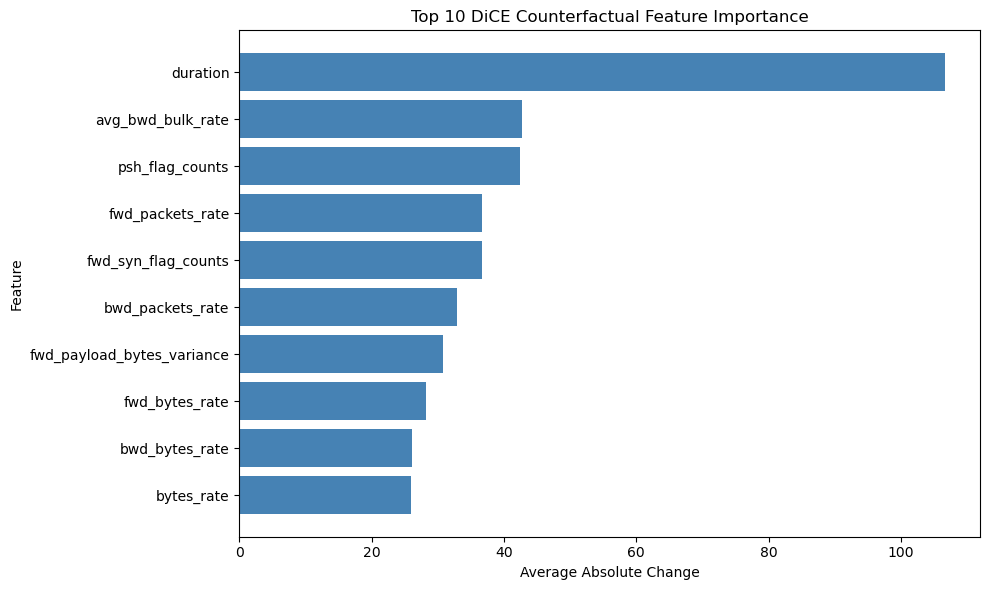

In [39]:
top10 = feature_importance.head(10)


plt.figure(figsize=(10,6))


plt.barh(

    top10["Feature"],

    top10["Average_Absolute_Change"],

    color="steelblue"

)


plt.xlabel(
    "Average Absolute Change"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Top 10 DiCE Counterfactual Feature Importance"
)


plt.gca().invert_yaxis()


plt.tight_layout()


plt.show()

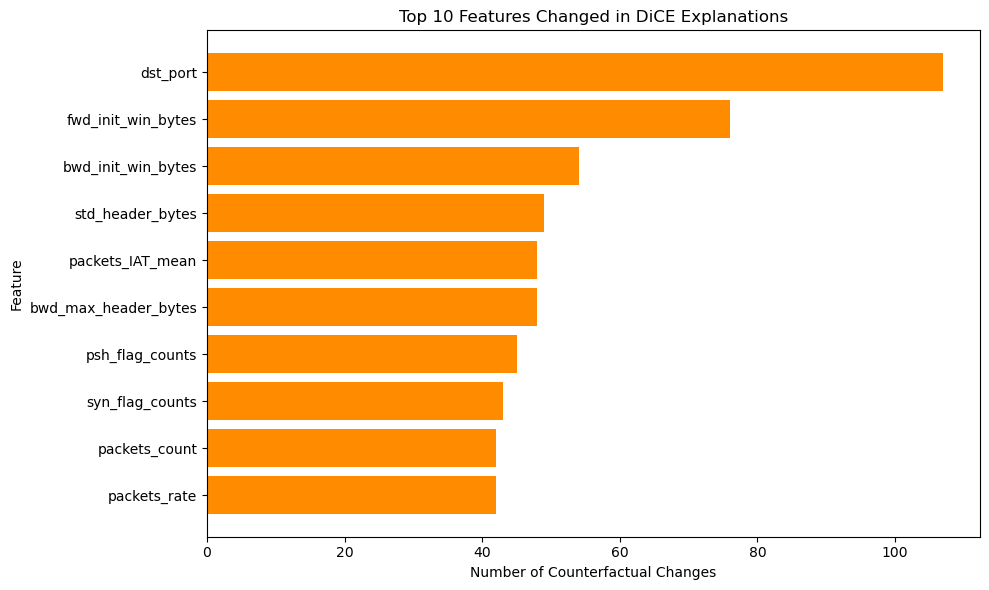

In [40]:
top10_frequency = frequency_importance.head(10)


plt.figure(figsize=(10,6))


plt.barh(

    top10_frequency["Feature"],

    top10_frequency["Number_of_Changes"],

    color="darkorange"

)


plt.xlabel(
    "Number of Counterfactual Changes"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Top 10 Features Changed in DiCE Explanations"
)


plt.gca().invert_yaxis()


plt.tight_layout()


plt.show()

In [41]:
final_dice_report = feature_importance.head(10)

final_dice_report

,Feature,Average_Absolute_Change
0,duration,106.592007
1,avg_bwd_bulk_rate,42.794908
2,psh_flag_counts,42.361749
3,fwd_packets_rate,36.677490
4,fwd_syn_flag_counts,36.649605
5,bwd_packets_rate,32.945719
6,fwd_payload_bytes_variance,30.764809
7,fwd_bytes_rate,28.167671
8,bwd_bytes_rate,26.126572
9,bytes_rate,26.031975


In [42]:
final_dice_report.to_csv(

    "DiCE_Final_Feature_Report.csv",

    index=False

)

print("Final DiCE report saved")

Final DiCE report saved


# Import required libraries

In [3]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import dice_ml
import time

from sklearn.metrics import pairwise_distances

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Layer,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention
)

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
train_data = pd.read_csv(
    "datasets/CICIDS2017/train_test/CICIDS2017_Train_80.csv"
)

print(train_data.shape)

(1948553, 41)


In [6]:
feature_names = (
    train_data
    .drop(columns=["label"])
    .columns
    .tolist()
)


DICE_TRAIN_SIZE = 50000


dice_train_df = train_data.sample(
    n=DICE_TRAIN_SIZE,
    random_state=42
)


print(dice_train_df.shape)

(50000, 41)


In [7]:
dice_data = dice_ml.Data(

    dataframe=dice_train_df,

    continuous_features=feature_names,

    outcome_name="label"

)

print("DICE data ready")

DICE data ready


In [8]:
@tf.keras.utils.register_keras_serializable()
class FeatureTokenizer(Layer):

    def __init__(self, num_features, embed_dim, **kwargs):
        super().__init__(**kwargs)

        self.num_features=num_features
        self.embed_dim=embed_dim
        self.proj=Dense(embed_dim)


    def build(self,input_shape):

        self.feature_embedding=self.add_weight(

            name="feature_embedding",

            shape=(1,self.num_features,self.embed_dim),

            initializer="random_normal",

            trainable=True

        )


    def call(self,x):

        x=tf.expand_dims(x,-1)

        x=self.proj(x)

        return x+self.feature_embedding



    def get_config(self):

        config=super().get_config()

        config.update({

            "num_features":self.num_features,
            "embed_dim":self.embed_dim

        })

        return config



@tf.keras.utils.register_keras_serializable()
class CLSToken(Layer):

    def build(self,input_shape):

        self.cls=self.add_weight(

            name="cls_token",

            shape=(1,1,input_shape[-1]),

            initializer="zeros",

            trainable=True

        )


    def call(self,x):

        batch=tf.shape(x)[0]

        cls=tf.repeat(
            self.cls,
            batch,
            axis=0
        )

        return tf.concat(
            [cls,x],
            axis=1
        )

In [9]:
@tf.keras.utils.register_keras_serializable()
class PositionEmbedding(Layer):

    def __init__(

        self,

        sequence_length,

        embed_dim,

        **kwargs

    ):

        super().__init__(**kwargs)

        self.sequence_length=sequence_length

        self.embed_dim=embed_dim

    def build(self,input_shape):

        self.pos_embedding=self.add_weight(

            name="position_embedding",

            shape=(1,self.sequence_length,self.embed_dim),

            initializer="random_normal",

            trainable=True

        )

    def call(self,x):

        return x+self.pos_embedding

    def get_config(self):

        config=super().get_config()

        config.update({

            "sequence_length":self.sequence_length,

            "embed_dim":self.embed_dim

        })

        return config



@tf.keras.utils.register_keras_serializable()
class TransformerBlock(Layer):

    def __init__(

        self,

        embed_dim,

        num_heads,

        ff_dim,

        dropout=0.15,

        **kwargs

    ):

        super().__init__(**kwargs)

        self.embed_dim=embed_dim

        self.num_heads=num_heads

        self.ff_dim=ff_dim

        self.dropout_rate=dropout

        self.norm1=LayerNormalization(epsilon=1e-6)

        self.att=MultiHeadAttention(

            num_heads=num_heads,

            key_dim=embed_dim//num_heads,

            dropout=dropout

        )

        self.drop1=Dropout(dropout)

        self.norm2=LayerNormalization(epsilon=1e-6)

        self.ffn=tf.keras.Sequential([

            Dense(ff_dim,activation="gelu"),

            Dropout(dropout),

            Dense(embed_dim)

        ])

        self.drop2=Dropout(dropout)

    def call(self,x,training=False):

        y=self.norm1(x)

        y=self.att(y,y,training=training)

        y=self.drop1(y,training=training)

        x=x+y

        y=self.norm2(x)

        y=self.ffn(y,training=training)

        y=self.drop2(y,training=training)

        return x+y

    def get_config(self):

        config=super().get_config()

        config.update({

            "embed_dim":self.embed_dim,

            "num_heads":self.num_heads,

            "ff_dim":self.ff_dim,

            "dropout":self.dropout_rate

        })

        return config

In [10]:
model = load_model(

    "Transformer_IDS_Final.keras",

    custom_objects={

        "FeatureTokenizer":FeatureTokenizer,

        "CLSToken":CLSToken,

        "PositionEmbedding":PositionEmbedding,

        "TransformerBlock":TransformerBlock

    },

    compile=False

)


print("Model loaded")

c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'transformer_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'transformer_block_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



Model loaded


In [11]:
dice_model = dice_ml.Model(

    model=model,

    backend="TF2",

    model_type="classifier"

)


explainer = dice_ml.Dice(

    dice_data,

    dice_model,

    method="random"

)


print("DICE explainer ready")

DICE explainer ready


# Select evaluation samples

In [12]:
DICE_EVAL_SAMPLES = 30

dice_eval_samples = (
    dice_train_df
    .drop(columns=["label"])
    .sample(
        n=DICE_EVAL_SAMPLES,
        random_state=42
    )
)

print(dice_eval_samples.shape)

(30, 40)


In [14]:
TARGET_CLASS = 1

validity_results = []

all_sparsity = []
all_diversity = []
generation_times = []


for idx in range(len(dice_eval_samples)):

    print(f"Processing {idx+1}/{DICE_EVAL_SAMPLES}")

    query = dice_eval_samples.iloc[idx:idx+1]


    start_time = time.time()


    try:

        cf_result = explainer.generate_counterfactuals(

            query,

            total_CFs=3,

            desired_class=TARGET_CLASS

        )


        end_time = time.time()


        generation_times.append(
            end_time-start_time
        )


        cf_df = (
            cf_result
            .cf_examples_list[0]
            .final_cfs_df
            .drop(columns=["label"])
        )


        original_df = query.copy()


        # -----------------------------
        # Counterfactual Validity
        # -----------------------------

        predictions = np.argmax(

            model.predict(
                cf_df,
                verbose=0
            ),

            axis=1

        )


        successful = np.sum(
            predictions == TARGET_CLASS
        )


        validity_results.append(

            successful / len(cf_df)

        )


        # -----------------------------
        # Sparsity
        # -----------------------------

        for i in range(len(cf_df)):


            changed_features = np.sum(

                np.abs(

                    cf_df.iloc[i].values -

                    original_df.iloc[0].values

                ) > 0.01

            )


            all_sparsity.append(
                changed_features
            )



        # -----------------------------
        # Diversity
        # -----------------------------

        if len(cf_df) > 1:

            diversity = np.mean(

                pairwise_distances(
                    cf_df.values
                )

            )


            all_diversity.append(
                diversity
            )


    except Exception as e:

        print(
            "Skipped sample:",
            idx+1,
            e
        )


print("DICE evaluation completed")

Processing 1/30


100%|██████████| 1/1 [00:04<00:00,  4.72s/it]


Processing 2/30


100%|██████████| 1/1 [00:58<00:00, 58.52s/it]


Processing 3/30


...

Processing 29/30


100%|██████████| 1/1 [23:11<00:00, 1391.37s/it]


Processing 30/30


100%|██████████| 1/1 [00:12<00:00, 12.42s/it]

DICE evaluation completed


In [15]:
print("Average Validity:", np.mean(validity_results))
print("Average Sparsity:", np.mean(all_sparsity))
print("Average Diversity:", np.mean(all_diversity))
print("Average Generation Time (seconds):", np.mean(generation_times))

print("\nSuccessful samples:", len(validity_results))
print("Failed samples:", len(dice_eval_samples) - len(validity_results))

Average Validity: 1.0
Average Sparsity: 13.407894736842104
Average Diversity: 24.362286800567947
Average Generation Time (seconds): 1318.9440493839127

Successful samples: 28
Failed samples: 2


In [16]:
summary_df = pd.DataFrame({
    "Metric": [
        "Validity",
        "Sparsity",
        "Diversity",
        "Generation_Time_sec"
    ],
    "Mean": [
        np.mean(validity_results),
        np.mean(all_sparsity),
        np.mean(all_diversity),
        np.mean(generation_times)
    ]
})

summary_df.to_csv("DiCE_Evaluation_Summary.csv", index=False)

print(summary_df)

                Metric         Mean
0             Validity     1.000000
1             Sparsity    13.407895
2            Diversity    24.362287
3  Generation_Time_sec  1318.944049


In [18]:
successful = len(validity_results)
total = len(dice_eval_samples)

print("Successful samples:", successful)
print("Total samples:", total)
print("Generation Success Rate:", successful / total)

Successful samples: 28
Total samples: 30
Generation Success Rate: 0.9333333333333333


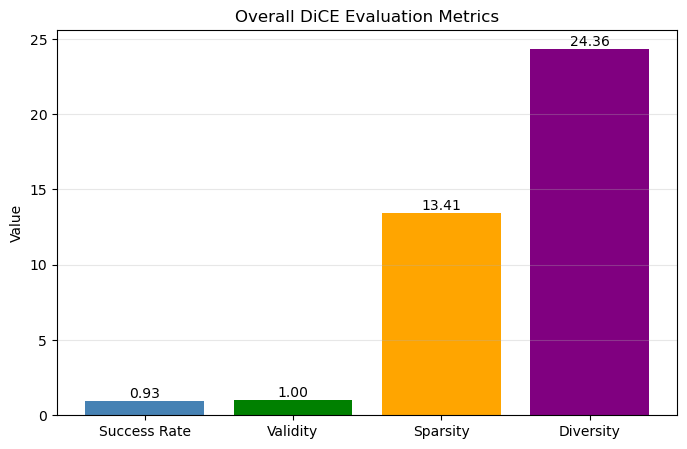

In [20]:
import matplotlib.pyplot as plt

metrics = ["Success Rate", "Validity", "Sparsity", "Diversity"]
values = [0.9333, 1.0, 13.41, 24.36]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values,
               color=["steelblue","green","orange","purple"])

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}",
             ha="center",
             va="bottom")

plt.ylabel("Value")
plt.title("Overall DiCE Evaluation Metrics")
plt.grid(axis="y", alpha=0.3)
plt.show()

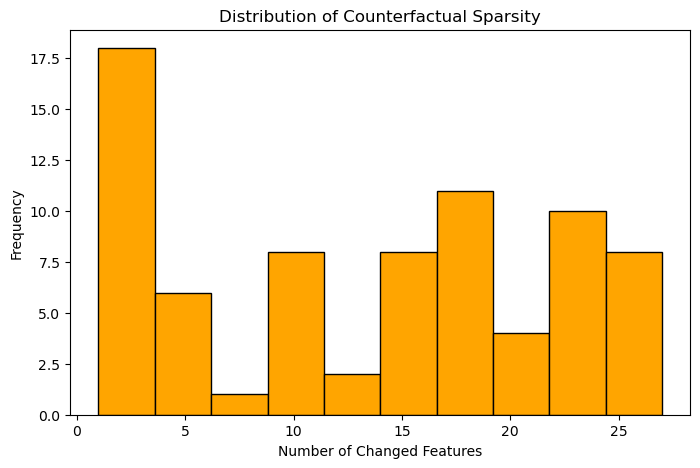

In [23]:
plt.figure(figsize=(8,5))

plt.hist(all_sparsity,
         bins=10,
         color="orange",
         edgecolor="black")

plt.xlabel("Number of Changed Features")
plt.ylabel("Frequency")
plt.title("Distribution of Counterfactual Sparsity")

plt.show()

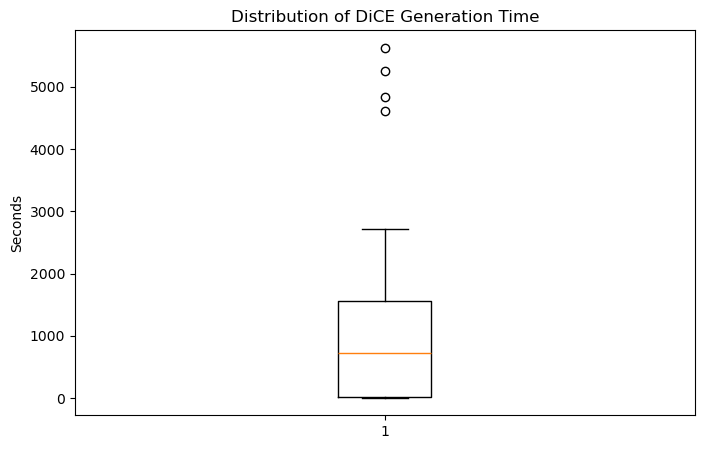

In [22]:
plt.figure(figsize=(8,5))

plt.boxplot(generation_times)

plt.ylabel("Seconds")
plt.title("Distribution of DiCE Generation Time")

plt.show()